## Company Market Cap Prediction

Given *data about big companies*, let's try to predict the **market capitalization** of a given company.

We will use a variety of regression models to make our predictions.

Data source: https://www.kaggle.com/datasets/winston56/fortune-500-data-2021

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
data = pd.read_csv('archive/Fortune_1000.csv')
data

,company,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,prev_rank,CEO,Website,Ticker,Market Cap
0,Walmart,1,0.0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,no,no,no,yes,1.0,C. Douglas McMillon,https://www.stock.walmart.com,WMT,352037
1,Amazon,2,0.0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,no,no,no,yes,2.0,Andrew R. Jassy,www.amazon.com,AMZN,1202717
2,Apple,3,0.0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,no,no,no,yes,3.0,Timothy D. Cook,www.apple.com,AAPL,2443962
3,CVS Health,4,0.0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,no,no,yes,yes,4.0,Karen Lynch,https://www.cvshealth.com,CVS,125204
4,UnitedHealth Group,5,0.0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,no,no,no,yes,5.0,Andrew P. Witty,www.unitedhealthgroup.com,UNH,500468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Vizio Holding,996,0.0,2124.0,-39.4,800.0,Industrials,Irvine,CA,no,yes,no,no,,William W. Wang,https://www.vizio.com,VZIO,1705.1
996,1-800-Flowers.com,997,0.0,2122.2,118.7,4800.0,Retailing,Jericho,NY,no,no,no,yes,,Christopher G. McCann,https://www.1800flowers.com,FLWS,830
997,Cowen,998,0.0,2112.8,295.6,1534.0,Financials,New York,NY,no,no,no,yes,,Jeffrey Solomon,https://www.cowen.com,COWN,1078
998,Ashland,999,0.0,2111.0,220.0,4100.0,Chemicals,Wilmington,DE,no,no,no,yes,,Guillermo Novo,https://www.ashland.com,ASH,5601.9


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   company            1000 non-null   str    
 1   rank               1000 non-null   int64  
 2   rank_change        1000 non-null   float64
 3   revenue            1000 non-null   float64
 4   profit             997 non-null    float64
 5   num. of employees  999 non-null    float64
 6   sector             1000 non-null   str    
 7   city               1000 non-null   str    
 8   state              1000 non-null   str    
 9   newcomer           1000 non-null   str    
 10  ceo_founder        1000 non-null   str    
 11  ceo_woman          1000 non-null   str    
 12  profitable         1000 non-null   str    
 13  prev_rank          1000 non-null   str    
 14  CEO                1000 non-null   str    
 15  Website            1000 non-null   str    
 16  Ticker             951 non-null    s

### Preprocessing

In [4]:
df = data.copy()

In [5]:
df['prev_rank'].replace(' ', np.nan).astype(float).isna().sum()

np.int64(531)

In [6]:
# Drop unused columns
df = df.drop(['company', 'CEO', 'Website', 'Ticker', 'prev_rank'], axis=1)
df

,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,Market Cap
0,1,0.0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,no,no,no,yes,352037
1,2,0.0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,no,no,no,yes,1202717
2,3,0.0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,no,no,no,yes,2443962
3,4,0.0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,no,no,yes,yes,125204
4,5,0.0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,no,no,no,yes,500468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,0.0,2124.0,-39.4,800.0,Industrials,Irvine,CA,no,yes,no,no,1705.1
996,997,0.0,2122.2,118.7,4800.0,Retailing,Jericho,NY,no,no,no,yes,830
997,998,0.0,2112.8,295.6,1534.0,Financials,New York,NY,no,no,no,yes,1078
998,999,0.0,2111.0,220.0,4100.0,Chemicals,Wilmington,DE,no,no,no,yes,5601.9


In [7]:
df.isna().sum()

rank                  0
rank_change           0
revenue               0
profit                3
num. of employees     1
sector                0
city                  0
state                 0
newcomer              0
ceo_founder           0
ceo_woman             0
profitable            0
Market Cap           31
dtype: int64

In [8]:
df.dtypes

rank                   int64
rank_change          float64
revenue              float64
profit               float64
num. of employees    float64
sector                   str
city                     str
state                    str
newcomer                 str
ceo_founder              str
ceo_woman                str
profitable               str
Market Cap               str
dtype: object

In [9]:
# Encode missing values
df['Market Cap'] = df['Market Cap'].replace('-', np.nan)

In [10]:
# Drop missing target rows
missing_target_rows = df[df['Market Cap'].isna()].index

df = df.drop(missing_target_rows, axis=0).reset_index(drop=True)

In [11]:
df

,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,Market Cap
0,1,0.0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,no,no,no,yes,352037
1,2,0.0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,no,no,no,yes,1202717
2,3,0.0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,no,no,no,yes,2443962
3,4,0.0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,no,no,yes,yes,125204
4,5,0.0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,no,no,no,yes,500468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,996,0.0,2124.0,-39.4,800.0,Industrials,Irvine,CA,no,yes,no,no,1705.1
957,997,0.0,2122.2,118.7,4800.0,Retailing,Jericho,NY,no,no,no,yes,830
958,998,0.0,2112.8,295.6,1534.0,Financials,New York,NY,no,no,no,yes,1078
959,999,0.0,2111.0,220.0,4100.0,Chemicals,Wilmington,DE,no,no,no,yes,5601.9


In [12]:
df.isna().sum()

rank                 0
rank_change          0
revenue              0
profit               3
num. of employees    0
sector               0
city                 0
state                0
newcomer             0
ceo_founder          0
ceo_woman            0
profitable           0
Market Cap           0
dtype: int64

In [13]:
# Fill missing values
df['profit'] = df['profit'].fillna(df['profit'].mean())

In [14]:
df.isna().sum()

rank                 0
rank_change          0
revenue              0
profit               0
num. of employees    0
sector               0
city                 0
state                0
newcomer             0
ceo_founder          0
ceo_woman            0
profitable           0
Market Cap           0
dtype: int64

In [15]:
{column: len(df[column].unique()) for column in df.select_dtypes('object').columns}

C:\Users\Aditya\AppData\Local\Temp\ipykernel_10524\749133970.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  {column: len(df[column].unique()) for column in df.select_dtypes('object').columns}


{'sector': 21,
 'city': 387,
 'state': 45,
 'newcomer': 2,
 'ceo_founder': 2,
 'ceo_woman': 2,
 'profitable': 2,
 'Market Cap': 958}

In [16]:
# Binary encoding 
for column in ['newcomer', 'ceo_founder', 'ceo_woman', 'profitable']:
    df[column] = df[column].replace({'no': 0, 'yes': 1})

In [17]:
df

,rank,rank_change,revenue,profit,num. of employees,sector,city,state,newcomer,ceo_founder,ceo_woman,profitable,Market Cap
0,1,0.0,572754.0,13673.0,2300000.0,Retailing,Bentonville,AR,0,0,0,1,352037
1,2,0.0,469822.0,33364.0,1608000.0,Retailing,Seattle,WA,0,0,0,1,1202717
2,3,0.0,365817.0,94680.0,154000.0,Technology,Cupertino,CA,0,0,0,1,2443962
3,4,0.0,292111.0,7910.0,258000.0,Health Care,Woonsocket,RI,0,0,1,1,125204
4,5,0.0,287597.0,17285.0,350000.0,Health Care,Minnetonka,MN,0,0,0,1,500468
...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,996,0.0,2124.0,-39.4,800.0,Industrials,Irvine,CA,0,1,0,0,1705.1
957,997,0.0,2122.2,118.7,4800.0,Retailing,Jericho,NY,0,0,0,1,830
958,998,0.0,2112.8,295.6,1534.0,Financials,New York,NY,0,0,0,1,1078
959,999,0.0,2111.0,220.0,4100.0,Chemicals,Wilmington,DE,0,0,0,1,5601.9


In [18]:
# One-Hot Encoding
def onehot_encode(df, columns, prefixes):
    df = df.copy()
    for column, prefix in zip(columns, prefixes):
        dummies = pd.get_dummies(df[column], dtype=int, prefix=prefix)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

columns = ['sector', 'city', 'state']
prefixes = ['se', 'c', 'st']

df = onehot_encode(df, columns, prefixes)

In [19]:
df

,rank,rank_change,revenue,profit,num. of employees,newcomer,ceo_founder,ceo_woman,profitable,Market Cap,...,st_PA,st_PR,st_RI,st_SC,st_TN,st_TX,st_UT,st_VA,st_WA,st_WI
0,1,0.0,572754.0,13673.0,2300000.0,0,0,0,1,352037,...,0,0,0,0,0,0,0,0,0,0
1,2,0.0,469822.0,33364.0,1608000.0,0,0,0,1,1202717,...,0,0,0,0,0,0,0,0,1,0
2,3,0.0,365817.0,94680.0,154000.0,0,0,0,1,2443962,...,0,0,0,0,0,0,0,0,0,0
3,4,0.0,292111.0,7910.0,258000.0,0,0,1,1,125204,...,0,0,1,0,0,0,0,0,0,0
4,5,0.0,287597.0,17285.0,350000.0,0,0,0,1,500468,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,996,0.0,2124.0,-39.4,800.0,0,1,0,0,1705.1,...,0,0,0,0,0,0,0,0,0,0
957,997,0.0,2122.2,118.7,4800.0,0,0,0,1,830,...,0,0,0,0,0,0,0,0,0,0
958,998,0.0,2112.8,295.6,1534.0,0,0,0,1,1078,...,0,0,0,0,0,0,0,0,0,0
959,999,0.0,2111.0,220.0,4100.0,0,0,0,1,5601.9,...,0,0,0,0,0,0,0,0,0,0


In [20]:
# Split df into X and y
y = df['Market Cap'].astype(float)
X = df.drop('Market Cap', axis=1)

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

In [22]:
X_train

,rank,rank_change,revenue,profit,num. of employees,newcomer,ceo_founder,ceo_woman,profitable,se_Aerospace & Defense,...,st_PA,st_PR,st_RI,st_SC,st_TN,st_TX,st_UT,st_VA,st_WA,st_WI
733,766,0.0,3409.0,250.0,4500.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
719,752,0.0,3497.6,115.6,10810.0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
341,362,-44.0,9722.0,-648.0,12684.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
291,308,-35.0,12222.0,1166.0,14400.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
46,48,-10.0,74196.0,-6520.0,168000.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,801,0.0,3208.1,-135.0,16300.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
72,75,22.0,48550.0,3282.8,340000.0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
908,947,0.0,2356.1,190.9,2104.0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
235,248,180.0,14643.0,2118.0,1932.0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [23]:
X_train.describe()

,rank,rank_change,revenue,profit,num. of employees,se_Aerospace & Defense,se_Apparel,se_Business Services,se_Chemicals,se_Energy,...,st_PA,st_PR,st_RI,st_SC,st_TN,st_TX,st_UT,st_VA,st_WA,st_WI
count,672.000000,672.000000,672.000000,672.000000,6.720000e+02,672.000000,672.000000,672.000000,672.000000,672.000000,...,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000,672.000000
mean,499.747024,-1.522321,17703.123810,1810.036164,3.735248e+04,0.013393,0.019345,0.052083,0.032738,0.111607,...,0.049107,0.001488,0.002976,0.002976,0.026786,0.099702,0.005952,0.031250,0.014881,0.017857
std,284.607715,31.843452,41489.991376,4797.809671,1.206522e+05,0.115036,0.137838,0.222361,0.178083,0.315117,...,0.216253,0.038576,0.054514,0.054514,0.161577,0.299826,0.076979,0.174122,0.121167,0.132531
min,1.000000,-178.000000,2107.200000,-6520.000000,1.600000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,256.250000,-3.250000,3540.875000,190.350000,6.626250e+03,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,501.500000,0.000000,6351.000000,579.350000,1.390000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,744.250000,0.000000,14238.000000,1523.500000,2.860875e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1000.000000,200.000000,572754.000000,76033.000000,2.300000e+06,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
# Scale X
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [25]:
X_train

,rank,rank_change,revenue,profit,num. of employees,newcomer,ceo_founder,ceo_woman,profitable,se_Aerospace & Defense,...,st_PA,st_PR,st_RI,st_SC,st_TN,st_TX,st_UT,st_VA,st_WA,st_WI
0,0.936205,0.047842,-0.344776,-0.325398,-0.272494,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,-0.179605,-0.122905,-0.13484
1,0.886978,0.047842,-0.342639,-0.353432,-0.220156,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,3.004971,-0.077382,-0.179605,-0.122905,-0.13484
2,-0.484350,-1.334947,-0.192506,-0.512706,-0.204612,-0.175142,-0.237915,-0.301511,-2.559407,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,-0.179605,-0.122905,-0.13484
3,-0.674226,-1.052104,-0.132206,-0.134335,-0.190378,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,-0.179605,-0.122905,-0.13484
4,-1.588444,-0.266428,1.362617,-1.737510,1.083651,-0.175142,-0.237915,-0.301511,-2.559407,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,-0.179605,-0.122905,-0.13484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,1.059273,0.047842,-0.349622,-0.405703,-0.174619,-0.175142,-0.237915,-0.301511,-2.559407,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,5.567764,-0.122905,-0.13484
668,-1.493506,0.739237,0.744031,0.307195,2.510298,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,-0.179605,-0.122905,-0.13484
669,1.572642,0.047842,-0.370173,-0.337725,-0.292367,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,-0.332782,-0.077382,5.567764,-0.122905,-0.13484
670,-0.885199,5.704706,-0.073811,0.064236,-0.293794,-0.175142,-0.237915,-0.301511,0.390716,-0.11651,...,-0.227251,-0.038605,-0.054636,-0.054636,-0.1659,3.004971,-0.077382,-0.179605,-0.122905,-0.13484


### Training

In [26]:
models = {
    'Linear Regression     ': LinearRegression(),
    'Linear Regression (L2)': Ridge(),
    'Linear Regression (L1)': Lasso(),
    'Decision Tree         ': DecisionTreeRegressor(),
    'Neural Network        ': MLPRegressor(),
    'Random Forest         ': RandomForestRegressor(),
    'Gradient Boosting     ': GradientBoostingRegressor()
}

In [27]:
for name, model in models.items():
    model.fit(X_train, y_train)
    print(name + " trained.")

Linear Regression      trained.
Linear Regression (L2) trained.
Linear Regression (L1) trained.


D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.860319e+11, tolerance: 5.784e+08
  model = cd_fast.enet_coordinate_descent(


Decision Tree          trained.


D:\miniconda3\envs\tfenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Neural Network         trained.
Random Forest          trained.
Gradient Boosting      trained.


### Results

In [30]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    print(f"RMSE for {name}: {rmse:.2f}")

RMSE for Linear Regression     : 123705.12
RMSE for Linear Regression (L2): 116325.47
RMSE for Linear Regression (L1): 122351.82
RMSE for Decision Tree         : 127779.55
RMSE for Neural Network        : 197829.21
RMSE for Random Forest         : 116048.61
RMSE for Gradient Boosting     : 116410.78


In [32]:
for name, model in models.items():
    r2 = model.score(X_test, y_test)
    print(f"RMSE for {name}: {r2:.5f}")

RMSE for Linear Regression     : 0.58459
RMSE for Linear Regression (L2): 0.63268
RMSE for Linear Regression (L1): 0.59363
RMSE for Decision Tree         : 0.55678
RMSE for Neural Network        : -0.06238
RMSE for Random Forest         : 0.63442
RMSE for Gradient Boosting     : 0.63214


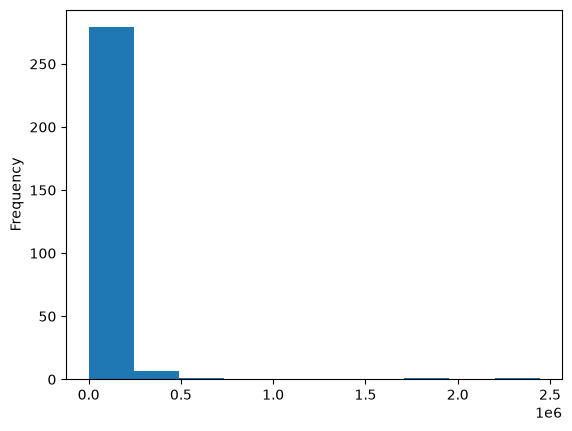

In [33]:
y_test.plot(kind='hist');

In [34]:
y_test.describe()

count    2.890000e+02
mean     5.014407e+04
std      1.922666e+05
min      4.026000e+02
25%      4.551600e+03
50%      1.260800e+04
75%      3.380250e+04
max      2.443962e+06
Name: Market Cap, dtype: float64